# CMB-S4 Neff paper 1 plots

In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import numpy as np, glob, healpy as H, os, sys, pickle
from pylab import *

import warnings
warnings.filterwarnings("ignore")
import logging
logging.getLogger().setLevel(logging.ERROR)


In [7]:
rcParams['figure.dpi'] = 150
rcParams['figure.facecolor'] = 'white'
rcParams['font.family'] = 'serif'

# Figures 2, 3, and 4



lat_wide
Patch = 1
	Noise thresholds [uK-arcmin] = (0.01, 2)
	Mean noise value = 1.77412 uK-arcmin
	fsky = 0.0810452 (3343 sq. deg)
Patch = 2
	Noise thresholds [uK-arcmin] = (2, 5)
	Mean noise value = 2.8917 uK-arcmin
	fsky = 0.341027 (14068 sq. deg)
Patch = 3
	Noise thresholds [uK-arcmin] = (5, 8)
	Mean noise value = 6.22067 uK-arcmin
	fsky = 0.0169312 (698 sq. deg)
Patch = 4
	Noise thresholds [uK-arcmin] = (8, 10000)
	Mean noise value = 29.3685 uK-arcmin
	fsky = 0.0286102 (1180 sq. deg)
Total fsky = 0.467613 (19290 sq. deg)

All band noise levels for lat_wide
Patch = 1: 41.3, 21.1, 11.4, 1.9, 1.8, 6.8, 19.9 uK-arcmin
Patch = 2: 67.7, 34.2, 18.5, 3.1, 2.9, 11.3, 33.1 uK-arcmin
Patch = 3: 151.2, 74.3, 40.3, 6.6, 6.2, 26.9, 78.9 uK-arcmin
Patch = 4: 205.8, 183.8, 100.0, 31.1, 29.4, 44.9, 132.0 uK-arcmin


<Figure size 900x600 with 0 Axes>

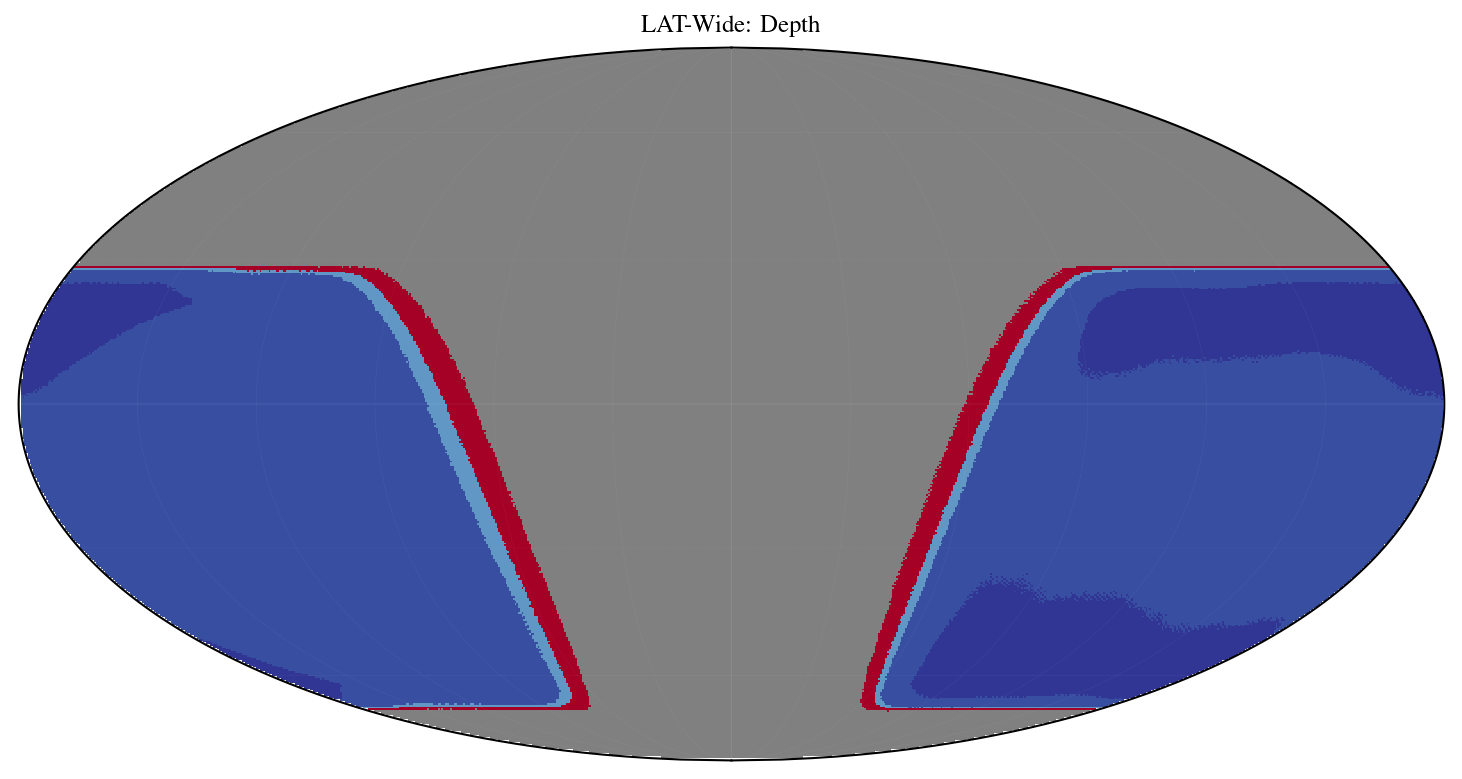

------------------------------


lat_delensing
Patch = 1
	Noise thresholds [uK-arcmin] = (0.01, 1)
	Mean noise value = 0.600043 uK-arcmin
	fsky = 0.0431302 (1779 sq. deg)
Patch = 2
	Noise thresholds [uK-arcmin] = (1, 2.5)
	Mean noise value = 1.5705 uK-arcmin
	fsky = 0.0210209 (867 sq. deg)
Patch = 3
	Noise thresholds [uK-arcmin] = (2.5, 5)
	Mean noise value = 3.53383 uK-arcmin
	fsky = 0.0103391 (426 sq. deg)
Patch = 4
	Noise thresholds [uK-arcmin] = (5, 10000)
	Mean noise value = 21.9324 uK-arcmin
	fsky = 0.0179469 (740 sq. deg)
Total fsky = 0.0924371 (3813 sq. deg)

All band noise levels for lat_delensing
Patch = 1: 14.0, 7.1, 3.8, 0.6, 0.6, 2.4, 6.9 uK-arcmin
Patch = 2: 39.0, 17.6, 9.6, 1.7, 1.6, 8.7, 25.5 uK-arcmin
Patch = 3: 67.2, 40.3, 21.9, 3.7, 3.5, 17.4, 51.2 uK-arcmin
Patch = 4: 165.6, 116.1, 63.2, 23.2, 21.9, 35.3, 104.2 uK-arcmin


<Figure size 900x600 with 0 Axes>

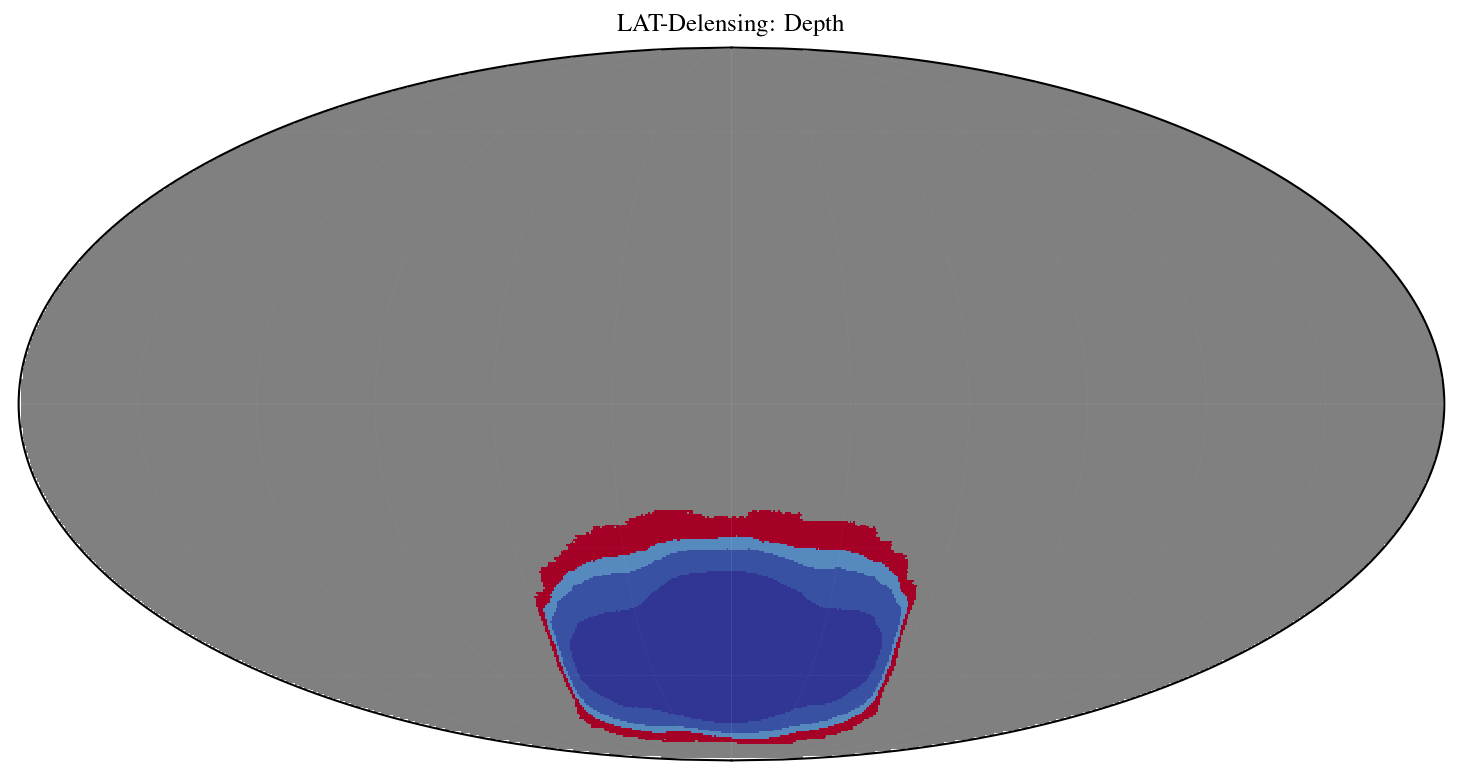

------------------------------


In [8]:
sim_fd = 'data/simulations/phase3/noise_depth/'
total_years = 10
band_arr = [20, 30, 40, 90, 150, 220, 280]
baseline_band = 150
depth_map_pref = 'lat_surveyval_fbandval_yearvalyears_depth.fits'

sim_fd_phase2 = 'data/simulations/phase2/noise_depth/'
depth_map_pref_phase2 = 'lat_wide_fbandval_yearvalyears_depth.fits'
total_years_phase2 = 14
dc0_band_dic = {20: 25, 30: 25, 40: 40, 90: 90, 150: 150, 220: 230, 280: 280}

sim_fd_dc0 = 'data/simulations/dc0'
depth_map_pref_dc0 = 'dc0_chlat_t01.01_bandval_map03.fits'
total_years_dc0 = 14

survey_dic = {
             ##'lat_wide_dc0': ['wide', r'LAT-Wide (DC0)'],
             ##'lat_wide_phase2': ['wide', r'LAT-Wide (Phase 2)'],
             'lat_wide': ['wide_supplement', r'LAT-Wide'],
             ##'lat_roman': ['roman_supplement', r'LAT-Roman'], 
             'lat_delensing': ['delensing_sun90bk', r'LAT-Delensing'], 
             }
vmin_vmax_dic = {'lat_roman': [0.5, 5.], 
                 'lat_delensing': [0.5, 5.], 
                 'lat_wide': [1.5, 8.], 
                 'lat_wide_phase2': [1.5, 4.], 
                 'lat_wide_dc0': [1., 2.], 
                }

use_absolute_or_relative_noise_thresholds = 'absolute'

#Planck gal mask stuff
# survey_arr_with_gal_contamination = ['lat_wide', 'lat_wide_phase2', 'lat_wide_dc0']
# planck_gal_mask_fname = 'data/HFI_Mask_GalPlane-apo0_2048_R2.00.fits'
# which_gal_frac_ind_dic = {'GAL070': 3, 'GAL080': 4, 'GAL090': 5}
# smoothing_beam = 2.

def get_depth_maps(band_arr, survey, sim_fd, depth_map_pref, total_years):
    depth_map_dic = {}
    for band in band_arr:
        if survey == 'lat_wide_phase2':
            depth_map_fname = '%s/%s' %(sim_fd_phase2, depth_map_pref_phase2)
            depth_map_fname = depth_map_fname.replace('surveyval', surveyval).replace('bandval', '%03d' %(band)).replace('yearval', '%02d' %(total_years_phase2))
            depth_map_fname = depth_map_fname.replace('lat_wide_phase2', 'lat_wide')
        elif survey == 'lat_wide_dc0':
            depth_map_fname = '%s/%s' %(sim_fd_dc0, depth_map_pref_dc0)
            depth_map_fname = depth_map_fname.replace('bandval', '%03d' %(dc0_band_dic[band]))
        else:
            depth_map_fname = '%s/%s' %(sim_fd, depth_map_pref)
            depth_map_fname = depth_map_fname.replace('surveyval', surveyval).replace('bandval', '%03d' %(band)).replace('yearval', '%02d' %(total_years))
            
        ##print( depth_map_fname )
        depth_map = H.read_map( depth_map_fname )
        if survey == 'lat_wide_dc0':
            depth_map = depth_map * 1e6
        depth_map_dic[band] = depth_map
            
        
    return depth_map_dic

#pick the depth map
parent_patch_dic = {}
parent_noise_val_dic = {}
for survey in survey_dic:

    print('\n')
    #------------------------------
    #get the depth map file name
    surveyval, surveylabval = survey_dic[survey]
    print( survey )
    #read the depth map
    depth_map_dic = get_depth_maps(band_arr, survey, sim_fd, depth_map_pref, total_years)
    baseline_depth_map = depth_map_dic[baseline_band]
    #------------------------------
    
    #------------------------------
    #plot
    vmin, vmax = vmin_vmax_dic[survey]
    ##H.mollview(depth_map, min = vmin, max = vmax, cmap = cmap, title = r'%s' %(surveylabval)); show()
    #------------------------------
    
    #------------------------------
    #pick patches
    #mask
    npix = len(baseline_depth_map)
    hmask = np.ones( npix )
    hmask[baseline_depth_map==0] = 0.
    unmasked_inds = np.where( hmask != 0 )[0]
    masked_inds = np.where( hmask == 0 )[0]
    
    hmap_patches = np.zeros( npix )
    hmap_patches_noisemap = np.zeros( npix )
    
    if use_absolute_or_relative_noise_thresholds == 'relative':
        medval = np.median( baseline_depth_map[unmasked_inds] )
        stdval = np.std( baseline_depth_map[unmasked_inds] )
        std_threshold_arr = np.asarray( [0., 0.05, 0.1, 0.25, 0.5, 1, 1e4] )
        threshold_arr = std_threshold_arr * stdval
    elif use_absolute_or_relative_noise_thresholds == 'absolute':
        if survey == 'lat_delensing':
            threshold_arr = [0.01, 1., 2.5, vmax, 1e4]
        elif survey == 'lat_roman':
            threshold_arr = [0.01, 1., 2.5, vmax, 1e4]
        elif survey == 'lat_wide':
            threshold_arr = [0.01, 2., 5., vmax, 1e4]
        elif survey in ['lat_wide_phase2']:
            #threshold_arr = [0.01, 2., vmax, 1e4]
            threshold_arr = [0.01, 6., 1e4]
        elif survey in ['lat_wide_dc0']:
            threshold_arr = [0.01, 6., 1e4]
            
    patch_dic = {}
    noise_val_dic = {}
    total_fsky = 0.
    for cntr, thresh1 in enumerate( threshold_arr[:-1] ):
        thresh2 = threshold_arr[cntr+1]
        
        if use_absolute_or_relative_noise_thresholds == 'relative':
            cond1 = abs(baseline_depth_map - medval) >= thresh1
            cond2 = abs(baseline_depth_map - medval) < thresh2
        elif use_absolute_or_relative_noise_thresholds == 'absolute':
            cond1 = baseline_depth_map >= thresh1
            cond2 = baseline_depth_map < thresh2
        curr_good_inds = np.where( (cond1) & (cond2) & (hmask!=0) )[0]
        #print(survey, cntr, thresh1, thresh2, curr_good_inds)
        noise_val_in_this_patch = np.mean( baseline_depth_map[curr_good_inds] )
        
        patchno = cntr+1
        hmap_patches[curr_good_inds] = patchno
        hmap_patches_noisemap[curr_good_inds] = noise_val_in_this_patch
        
        #calcualte noise value for all bands now
        curr_patch_noise_val_in_this_patch_dic = {}
        for band in band_arr:
            curr_patch_noise_val_in_this_patch_dic[band] = np.mean( depth_map_dic[band][curr_good_inds] )
            '''
            if cntr == 1:
                if band == 280:
                    print(np.sum(depth_map_dic[band][curr_good_inds]))
                    print( 'hi', band, np.mean( depth_map_dic[band][curr_good_inds] ) )
                    sys.exit()
            '''

        ##print(noise_val_in_this_patch_dic); sys.exit()
        noise_val_dic[patchno] = curr_patch_noise_val_in_this_patch_dic
        
        patch_dic[patchno] = np.zeros( npix )
        patch_dic[patchno][curr_good_inds] = 1
        curr_fsky = np.mean(patch_dic[patchno]**2.)

        total_fsky += curr_fsky
        #print( thresh1, thresh2, len(curr_good_inds), noise_val_in_this_patch, curr_fsky, total_fsky )
        total_sky_area = 41253.
        print('Patch = %s' %(patchno))
        print('\tNoise thresholds [uK-arcmin] = (%g, %g)' %(thresh1, thresh2))
        print('\tMean noise value = %g uK-arcmin' %(noise_val_in_this_patch))
        #print('\tMean noise in all bands', noise_val_dic[patchno])
        print('\tfsky = %g (%d sq. deg)' %(curr_fsky, curr_fsky * total_sky_area))
        #print('\tTotal fsky = %g' %(total_fsky))
        ##sys.exit()
        
    print('Total fsky = %g (%d sq. deg)' %(total_fsky, total_fsky * total_sky_area))
        
    #print all band noise levels
    print('\nAll band noise levels for %s' %(survey))
    for patchno in noise_val_dic:
        to_print_str = ''
        for band in noise_val_dic[patchno]:
            to_print_str = '%s, %.1f' %(to_print_str, noise_val_dic[patchno][band])
        to_print_str = to_print_str.strip(', ')
        to_print_str = 'Patch = %s: %s uK-arcmin' %(patchno, to_print_str)
        print(to_print_str)
        
    parent_patch_dic[survey] = patch_dic
    parent_noise_val_dic[survey] = noise_val_dic
    #------------------------------
    #plotting stuffs below
        
    bad_inds = np.where( (hmap_patches==0.) | (hmask == 0) )
    hmap_patches[bad_inds] = H.UNSEEN
    hmap_patches_noisemap[bad_inds] = H.UNSEEN
    good_inds = np.where( (hmap_patches!=0.) & (hmask!= 0) & (hmap_patches!=H.UNSEEN) )
        
    clf()
    figure(figsize = (10., 5.))
    subplots_adjust(wspace = 0.05)
    
    vmin, vmax = vmin_vmax_dic[survey]
    cmap = cm.RdYlBu_r
    H.mollview(baseline_depth_map, 
               cmap = cmap, 
               title = r'%s: Depth map' %(surveylabval), 
               min = vmin, max = vmax,
               sub = (121), 
               unit = r'$\mu$K-arcmin',
              )
    H.graticule(lw = 0.2, alpha = 0.2, color = 'white')
    
    if len(threshold_arr) == 5:
        cmap_patches = mpl.colors.ListedColormap(['steelblue', 'darkgreen', 'goldenrod', 'orangered'])
    elif len(threshold_arr) == 4:
        cmap_patches = mpl.colors.ListedColormap(['steelblue', 'darkgreen', 'orangered'])
    elif len(threshold_arr) == 3:
        cmap_patches = mpl.colors.ListedColormap(['steelblue', 'orangered'])
    ##print(len(threshold_arr)); sys.exit()
    
    if (0):
        bounds = np.unique( hmap_patches[good_inds] )
        norm = mpl.colors.BoundaryNorm(bounds, cmap_patches.N)
        H.mollview(hmap_patches, 
                   cmap = cmap_patches, 
                   title = r'%s: Patches' %(surveylabval), 
                   min = min(hmap_patches[good_inds]), max = max(hmap_patches[good_inds]),
                   sub = (122), 
                   unit = r'Number',
                  )
        H.graticule(lw = 0.2, alpha = 0.2, color = 'white')
        show()


        #cmap_noise = (mpl.colors.ListedColormap(['steelblue', 'darkgreen', 'goldenrod', 'orangered']))
        #bounds = np.unique( hmap_patches_noisemap[good_inds] )
        #norm = mpl.colors.BoundaryNorm(bounds, cmap_noise.N)
        #cmap = cmap_noise
        H.mollview(hmap_patches_noisemap, 
                   cmap = cmap, 
                   title = r'%s: Depth' %(surveylabval), 
                   min = min(hmap_patches_noisemap[good_inds]), max = max(hmap_patches_noisemap[good_inds]),
                   sub = (111), 
                   unit = r'$\mu$K-arcmin',
                  )
        H.graticule(lw = 0.2, alpha = 0.2, color = 'white')
        show(); 
    if (1): #footprint / noise levels
        clf()
        H.mollview(hmap_patches_noisemap, 
                   cmap = cmap, 
                   title = r'%s: Depth' %(surveylabval), 
                   min = min(hmap_patches_noisemap[good_inds]), max = max(hmap_patches_noisemap[good_inds]),
                   sub = (111), 
                   cbar = False
                  )
        H.graticule(lw = 0.2, alpha = 0.2, color = 'white')
        show(); 
    #------------------------------
    print('------------------------------')
    
    

# Figure 6:
## Neff from S4-only (wide+deep) and All-Chile (S4+ASO) configs.

aso_opt+final


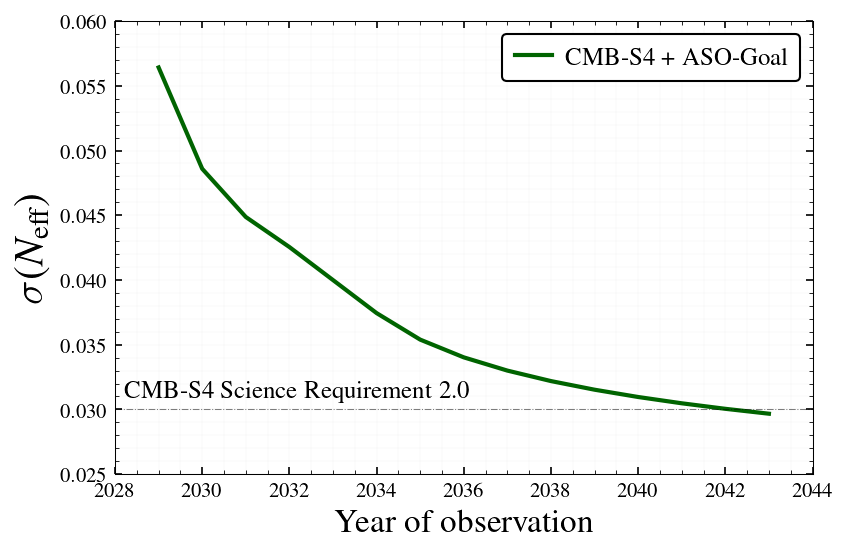

In [9]:
fname = 'results/neff/consolidated_s4_allchile_config_results.npy'
pldict = np.load( fname, allow_pickle= True ).item()

clf()
surveys_to_plot = ['aso_opt+final']
ax = subplot(111)
fsval = 14
lwval = 2.
actual_stat_year_for_aso = 2028
actual_stat_year_for_s4 = 2033
ymin, ymax = 0.025, 0.06
xmin, xmax = actual_stat_year_for_aso, actual_stat_year_for_s4 + 11

pl_specs_dic = {
             'aso_opt': [r'ASO-Goal', 'steelblue'], 
             'final': [r'CMB-S4', 'black'], 
             'aso_opt+final': [r'CMB-S4 + ASO-Goal', 'darkgreen'], 
            }


for surveyname in pldict:
    if surveyname not in surveys_to_plot: continue
    print(surveyname)
    xarr, yarr = pldict[surveyname]
    labval, colorval = pl_specs_dic[surveyname]
    plot(xarr, yarr, lw = lwval, color = colorval, label = labval)
    
axhline(0.03, lw = 0.5, alpha = 0.5, ls = '-.')
text(actual_stat_year_for_aso + .2, 0.031, r'CMB-S4 Science Requirement 2.0', fontsize = fsval-2)
if (0):
    axvline( actual_stat_year_for_s4, lw = 0.5, alpha = 0.5, ls = '--')
    text(actual_stat_year_for_s4 + .2, 0.0405, r'CMB-S4 starts operation', rotation = 90., fontsize = fsval-2)
ylim( ymin, ymax )
xlim( xmin, xmax )
legend(loc = 1, fontsize = fsval-2, ncol = 1, framealpha = 1., columnspacing = 0.5, handletextpad = 0.5, handlelength = 1.5)
ylabel(r'$\sigma(N_{\rm eff})$', fontsize = fsval + 6)
xlabel(r'Year of observation', fontsize = fsval + 2 )
#title(r'%s' %(title_str), fontsize = fsval + 2)
grid(True, which = 'both', axis = 'both', lw = 0.2, alpha = 0.05)
    